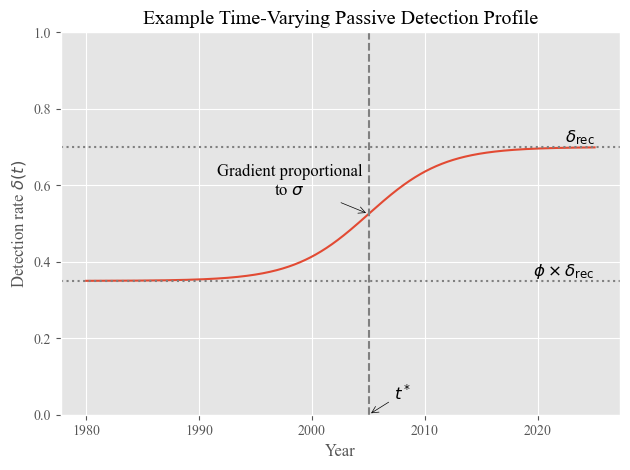

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["font.family"] = "Times New Roman"
plt.style.use("ggplot")

FIG_DIR = Path.cwd().parent / "appendix" / "figures"

# -----------------------
# Parameters
# -----------------------
delta_rec = .7
phi = 0.5
sigma = 0.15
t_star = 2005

# -----------------------
# Time grid: 1980–2025
# -----------------------
t = np.linspace(1980, 2025, 1000)

# -----------------------
# Profile definition
# -----------------------
delta = delta_rec * (
    phi +
    (1 - phi) * (
        np.tanh(sigma * (t - t_star)) / 2 + 0.5
    )
)

# -----------------------
# Plot
# -----------------------
plt.figure()
plt.plot(t, delta)

plt.xlabel("Year")
plt.ylabel(r"Detection rate $\delta(t)$")
plt.title("Example Time-Varying Passive Detection Profile")

# Transition year
plt.axvline(t_star, linestyle="--", color="gray")
plt.annotate(
    "$t^*$",
    xy=(t_star, 0.),          # point to
    xytext=(t_star + 3, 0.04),  # text position
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12, ha="center"
)

# Point at t*
delta_tstar = delta_rec * (phi + (1 - phi) * 0.5)

# Arrow + annotation
plt.annotate(
    "Gradient proportional\nto $\\sigma$",
    xy=(t_star, delta_tstar),          # point to
    xytext=(t_star - 7, delta_tstar + 0.05),  # text position
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12, ha="center"
)

# Recent level
plt.axhline(delta_rec, linestyle=":", color="gray")
plt.text(2025, delta_rec, r"$\delta_{\mathrm{rec}}$",
         va="bottom", ha="right", fontsize=12)

# Early baseline level
delta_early = delta_rec * phi
plt.axhline(delta_early, linestyle=":", color="gray")
plt.text(2025, delta_early, r"$\phi \times \delta_{\mathrm{rec}}$",
         va="bottom", ha="right", fontsize=12)

plt.ylim(bottom=0, top=1)
plt.tight_layout()
# plt.show()


plt.savefig(FIG_DIR / "pdetection_profile.pdf")
